In [ ]:
!wget https://drive.google.com/uc?id=1dhh4m9VRLUSmbaHfge2iRSW5Azkpefco  -O kitty3.png
!wget https://drive.google.com/uc?id=1o0UMPTyUFzX9CaQp-BwYXgkCho1Zo6yL  -O kitty55.png
!wget https://drive.google.com/uc?id=1Jk0cEtQt4HxkLcKlmTHukpb22gJZ4dmL -O noisy_kitty55.png
!wget https://drive.google.com/uc?id=1xCNA5338nzj1GgGQ5-oBA1dKCW1Mvn21 -O hillbefore_noise10%.jpg


--2025-10-16 03:19:54--  https://drive.google.com/uc?id=1dhh4m9VRLUSmbaHfge2iRSW5Azkpefco
Resolving drive.google.com (drive.google.com)... 74.125.68.138, 74.125.68.113, 74.125.68.102, ...
Connecting to drive.google.com (drive.google.com)|74.125.68.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1dhh4m9VRLUSmbaHfge2iRSW5Azkpefco [following]
--2025-10-16 03:19:54--  https://drive.usercontent.google.com/download?id=1dhh4m9VRLUSmbaHfge2iRSW5Azkpefco
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.10.132, 2404:6800:4003:c0f::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.10.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1194851 (1.1M) [image/png]
Saving to: ‘kitty3.png’

kitty3.png          100%[===================>]   1.14M  --.-KB/s    in 0.02s   

2025-10-16 03:19:55 (57.8 MB/s) - ‘kitty3.png’ saved [

In [ ]:
import cv2
img = cv2.imread('kitty3.png')
print(img.shape)
img = cv2.imread('kitty55.png')
print(img.shape)
img = cv2.imread('noisy_kitty55.png')
print(img.shape)


(1000, 1000, 3)
(500, 500, 3)
(500, 500, 3)


# L10 Object Recognition Part I

In [ ]:
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import data, exposure
import cv2
import numpy as np

## Histogram of Oriented Gradient (HOG)

* simple image

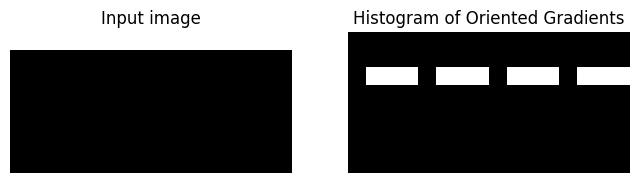

In [ ]:
image = np.array([[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
                  ,[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
                  ,[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
                  ,[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
                  ,[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]])

fd, hog_image = hog(image, orientations=5, pixels_per_cell=(4, 4), cells_per_block=(2, 2), visualize=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')


ax2.axis('off')
ax2.imshow(hog_image, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()

In [ ]:
  print(fd.shape)

(60,)


* Astronaut image

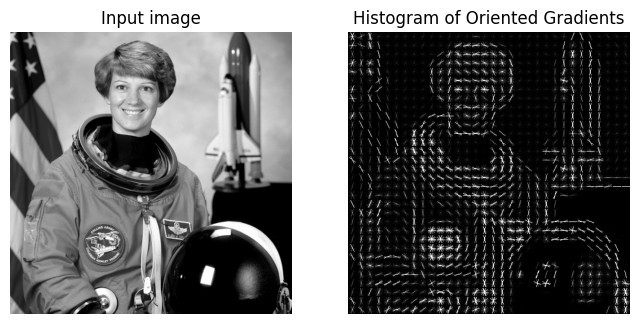

In [ ]:
image = data.astronaut()
image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)


# TO DO : Select different orientaion, pixels_per_cell and cells_per_block and analyze the results
fd, hog_image = hog(image, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2), visualize=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()



## HOG + Neural Networks



* MNIST dataset

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import hog
from keras.datasets import mnist

# ----------------------------
# 1. Load MNIST dataset
# ----------------------------
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# ----------------------------
# 2. Split train / validation / test sets
# ----------------------------
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

# ----------------------------
# 3. Preprocessing
# ----------------------------
# Normalize pixel values to [0, 1]
x_train = x_train / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# ----------------------------
# 4. Compute HOG features
# ----------------------------
def extract_hog_features(images):
    features = []
    for img in images:
        hog_feature = hog(
            img,
            orientations=9,
            pixels_per_cell=(7, 7),
            cells_per_block=(2, 2)
        )
        features.append(hog_feature)
    return np.array(features)

print("Computing HOG features ...")
X_train_hog = extract_hog_features(x_train)
X_val_hog   = extract_hog_features(x_val)
X_test_hog  = extract_hog_features(x_test)

print("HOG feature shape:", X_train_hog.shape)

# ----------------------------
# 5. Build Neural Network model
# ----------------------------
model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    batch_size=128,
    max_iter=20,
    random_state=42,
    verbose = 1
)

# ----------------------------
# 6. Train the model
# ----------------------------
print("Training Neural Network ...")
model.fit(X_train_hog, y_train)

# ----------------------------
# 7. Evaluate performance
# ----------------------------
y_pred_val = model.predict(X_val_hog)
y_pred_test = model.predict(X_test_hog)

print("Validation accuracy:", accuracy_score(y_val, y_pred_val))
print("Test accuracy:", accuracy_score(y_test, y_pred_test))
print("\nClassification Report (Test):\n", classification_report(y_test, y_pred_test))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Computing HOG features ...
HOG feature shape: (48000, 324)
Training Neural Network ...
Iteration 1, loss = 0.39965454
Iteration 2, loss = 0.13205272
Iteration 3, loss = 0.10939313
Iteration 4, loss = 0.09458296
Iteration 5, loss = 0.08354383
Iteration 6, loss = 0.07584269
Iteration 7, loss = 0.06858298
Iteration 8, loss = 0.06354502
Iteration 9, loss = 0.05883747
Iteration 10, loss = 0.05294656
Iteration 11, loss = 0.04910805
Iteration 12, loss = 0.04470576
Iteration 13, loss = 0.04213044
Iteration 14, loss = 0.04005390
Iteration 15, loss = 0.03596592
Iteration 16, loss = 0.03377508
Iteration 17, loss = 0.03133425
Iteration 18, loss = 0.02915637
Iteration 19, loss = 0.02724999
Iteration 20, loss = 0.02469732
Validation accuracy: 0.9773333333333334
Test accuracy: 0.9767

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99     

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


* Inferencing

In [ ]:
fd_test.shape

(324,)

[9]


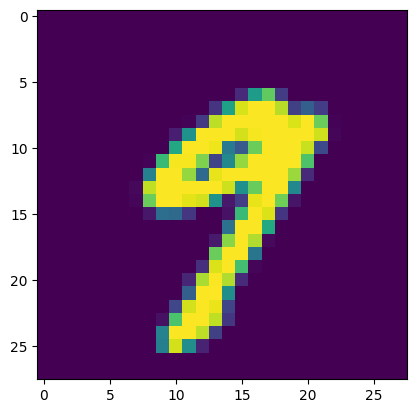

In [ ]:
fd_test = hog(x_test[20].reshape((28,28))/255.0, orientations=9, pixels_per_cell=(7,7),cells_per_block=(2,2))
print(model.predict(fd_test.reshape(1,324)))

plt.imshow(x_test[20])
plt.show()

## Convolutional Neural Networks (CNN)



In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchsummary import summary

### Prep data

In [ ]:
train_data = datasets.MNIST(
    root = 'data',
    train = True,
    transform = ToTensor(),
    download = True,
)
test_data = datasets.MNIST(
    root = 'data',
    train = False,
    transform = ToTensor()
)

train_data, val_data = random_split(train_data,[50000,10000])


batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(train_data, batch_size=batch_size)
val_dataloader = DataLoader(val_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

for X, y in val_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break



100%|██████████| 9.91M/9.91M [00:01<00:00, 4.96MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.1MB/s]

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [ ]:
print((5*5*1+1)*16)

### Prep model

In [ ]:
# Creating Models
# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

import torch.nn.functional as F
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=5,
                stride=1,
                padding=2,
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 5, 1, 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # fully connected layer, output 10 classes
        self.out = nn.Linear(32 * 7 * 7, 10)
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)

        # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        x = x.view(x.size(0), -1)
        output = F.log_softmax(self.out(x), dim=1)
        return output




model = Net().to(device)
print(model)

summary(model, input_size=(1, 28, 28))

# Optimizing the Model Parameters
loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)




Using cuda device
Net(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1568, out_features=10, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             416
       BatchNorm2d-2           [-1, 16, 28, 28]              32
              ReLU-3           [-1, 16, 28, 28]               0
         MaxPool2d-4           [-1, 16, 14, 14]               0
            Conv2d-5           [-1, 

In [ ]:
print((5*5*1 + 1)*16)

416


In [ ]:
print((5*5*1 + 1)*16)
print((5*5*16 + 1)*32)
print((7*7*32+1)*10)
print()

416
12832
15690



### Training

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)

        # print(type(pred),type(y))
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")



def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Accuracy: {(100*correct):>0.1f}%,  Avg loss: {test_loss:>8f} \n")

def val(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Val Accuracy: {(100*correct):>0.1f}%,  Avg loss: {test_loss:>8f} \n")

epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    val(val_dataloader, model, loss_fn)
print("Done!")


### Inferencing

In [ ]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

_model = Net().to(device)
weights=torch.load("model.pth")
_model.load_state_dict(weights)

print("Test accuracy")
test(test_dataloader, _model, loss_fn)



# L11 Object Recognition II

### visualizing filters

In [ ]:
from torchvision import utils

def visTensor(tensor, ch=0, allkernels=False, nrow=8, padding=1):
    n,c,w,h = tensor.shape

    if allkernels: tensor = tensor.view(n*c, -1, w, h)
    elif c != 3: tensor = tensor[:,ch,:,:].unsqueeze(dim=1)

    # rows = np.min((tensor.shape[0] // nrow + 1, 64))
    rows = tensor.shape[0] // nrow + 1
    grid = utils.make_grid(tensor, nrow=nrow, normalize=True, padding=padding)
    plt.figure( figsize=(nrow,rows) )
    plt.imshow(grid.detach().cpu().numpy().transpose((1, 2, 0)))





filter = model.conv1[0].weight.data.clone()
visTensor(filter, ch=0, allkernels=False)

plt.axis('off')
plt.title("conv1")
plt.ioff()
plt.show()


layer = 0
filter = model.conv2[0].weight.data.clone()
visTensor(filter, ch=0, allkernels=False)

plt.axis('off')
plt.ioff()
plt.title("conv2")
plt.show()

### visualizing feature maps

In [ ]:
summary(model, input_size=(1, 28, 28))
print(model)

In [ ]:
# we will save the conv layer weights in this list
model_weights =[]
conv_layers = []
# get all the model children as list
model_children = list(model.children())
# counter to keep count of the conv layers
counter = 0
# append all the conv layers and their respective wights to the list
for i in range(len(model_children)):
    if type(model_children[i]) == nn.Conv2d:
        counter+=1
        model_weights.append(model_children[i].weight)
        conv_layers.append(model_children[i])
    elif type(model_children[i]) == nn.Sequential:
        for j in range(len(model_children[i])):
            if type(model_children[i][j]) == nn.Conv2d:
                counter+=1
                model_weights.append(model_children[i][j].weight)
                conv_layers.append(model_children[i][j])
print(f"Total convolution layers: {counter}")


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Set model to eval
model.eval()

# Get prediction
X, y = test_data[105][0], test_data[105][1]
print(X.shape)
with torch.no_grad():
    output = model(X.unsqueeze(0).to(device))
    predicted, actual = output[0].argmax(0), y
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

print(output)



outputs = []
names = []
image = X.unsqueeze(0).to(device)
for layer in conv_layers[0:]:
    image = layer(image)
    outputs.append(image)
    names.append(str(layer))

processed = []
for feature_map in outputs:
    feature_map = feature_map.squeeze(0)
    gray_scale = torch.sum(feature_map,0)
    gray_scale = gray_scale / feature_map.shape[0]
    processed.append(gray_scale.data.cpu().numpy())



for i in range(len(processed)):
    plt.imshow(processed[i],cmap='jet')
    plt.show()
plt.savefig(str('feature_maps.jpg'), bbox_inches='tight')
plt.show()



## Exercise #1 Augmentation

In [ ]:
!wget https://drive.google.com/uc?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe -O kitty.jpg

--2025-10-24 14:00:42--  https://drive.google.com/uc?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe
Resolving drive.google.com (drive.google.com)... 142.250.101.102, 142.250.101.100, 142.250.101.101, ...
Connecting to drive.google.com (drive.google.com)|142.250.101.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe [following]
--2025-10-24 14:00:42--  https://drive.usercontent.google.com/download?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.2.132, 2607:f8b0:4023:c0d::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.2.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 79570 (78K) [image/jpeg]
Saving to: ‘kitty.jpg’

kitty.jpg           100%[===================>]  77.71K  --.-KB/s    in 0.03s   

2025-10-24 14:00:44 (2.19 MB/s) - ‘kitty.jpg’ saved

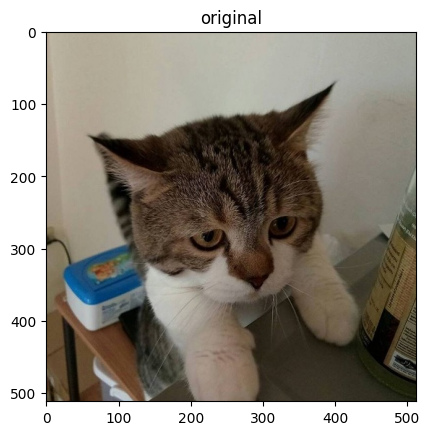

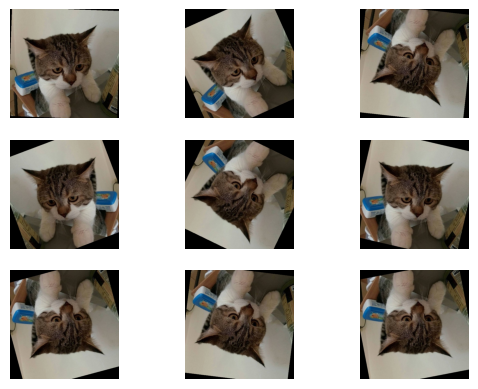

In [ ]:
from torchvision import transforms

# define transformations
data_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(0.3),
        transforms.RandomVerticalFlip(0.3),
        transforms.RandomRotation((-30,30)),
        transforms.ToTensor(),
])

from PIL import Image
import numpy as np
im = Image.open("kitty.jpg")

plt.imshow(im)
plt.title("original")
plt.show()

for i in range(1,10):
  img_tr=data_transform(im).numpy()
  plt.subplot(3,3,i)
  plt.imshow(img_tr.transpose(1,2,0));
  plt.axis('off')
plt.show()

### Augmentation with MNIST dataset

In [ ]:
# define transformations
data_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(0.3),
        transforms.RandomVerticalFlip(0.3),
        transforms.RandomRotation((-30,30)),
        transforms.ToTensor(),
])

train_data = datasets.MNIST(
    root = 'data',
    train = True,
    # transform = ToTensor(),
    transform = data_transform,
    download = True,
)
test_data = datasets.MNIST(
    root = 'data',
    train = False,
    transform = ToTensor()
)

train_data, val_data = random_split(train_data,[50000,10000])


batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(train_data, batch_size=batch_size)
val_dataloader = DataLoader(val_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

for X, y in val_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break


# Creating Models
# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

import torch.nn.functional as F
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=5,
                stride=1,
                padding=2,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 5, 1, 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # fully connected layer, output 10 classes
        self.out = nn.Linear(32 * 7 * 7, 10)
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)

        # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        x = x.view(x.size(0), -1)
        output = F.log_softmax(self.out(x), dim=1)
        return output




model = Net().to(device)
print(model)

summary(model, input_size=(1, 28, 28))

# Optimizing the Model Parameters
loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)


def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)

        # print(type(pred),type(y))
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")



def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Accuracy: {(100*correct):>0.1f}%,  Avg loss: {test_loss:>8f} \n")

def val(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Val Accuracy: {(100*correct):>0.1f}%,  Avg loss: {test_loss:>8f} \n")

epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    val(val_dataloader, model, loss_fn)
print("Done!")



torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

_model = Net().to(device)
weights=torch.load("model.pth")
_model.load_state_dict(weights)

print("Test accuracy")
test(test_dataloader, _model, loss_fn)


Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Using cuda device
Net(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1568, out_features=10, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             416
              ReLU-2           [-1,

## Vision transformer


In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [ ]:
# 1. Multi-Head Self-Attention
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        q, k, v = qkv[:, :, 0], qkv[:, :, 1], qkv[:, :, 2]
        q, k, v = q.transpose(1, 2), k.transpose(1, 2), v.transpose(1, 2)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj(out)

# 2. Transformer Encoder Block
class TransformerEncoder(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * mlp_ratio),
            nn.GELU(),
            nn.Linear(dim * mlp_ratio, dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

# 3. Sin–Cos 2D Positional Encoding
class PositionalEncoding2D(nn.Module):
    def __init__(self, num_patches, dim):
        super().__init__()
        grid_size = int(math.sqrt(num_patches))
        assert grid_size ** 2 == num_patches, "num_patches must form a square grid"
        self.register_buffer("pos_embed", self.build_2d_sincos(dim, grid_size))

    def build_2d_sincos(self, dim, grid):
        assert dim % 2 == 0, "embedding dim must be divisible by 2"
        dim_half = dim // 2
        grid_y, grid_x = torch.meshgrid(
            torch.arange(grid, dtype=torch.float32),
            torch.arange(grid, dtype=torch.float32),
            indexing="ij"
        )
        pos_x = self.get_1d_sincos(grid_x.flatten(), dim_half)
        pos_y = self.get_1d_sincos(grid_y.flatten(), dim_half)
        pos = torch.cat([pos_x, pos_y], dim=1)
        return pos.unsqueeze(0)  # shape (1, num_patches, dim)

    def get_1d_sincos(self, pos, dim):
        omega = torch.arange(dim // 2, dtype=torch.float32) / (dim / 2)
        omega = 1. / (10000 ** omega)
        out = pos[:, None] * omega[None, :]
        sin, cos = torch.sin(out), torch.cos(out)
        return torch.cat([sin, cos], dim=1)

    def forward(self, x):
        return x + self.pos_embed.to(x.device)

# 3. Alternate Position Encoding using Learnable Paramters
# class PositionalEncoding2D(nn.Module):
#     def __init__(self, num_patches, dim):
#         super().__init__()
#         self.pos_embed = nn.Parameter(torch.randn(1, num_patches, dim))

#     def forward(self, x):
#         return x + self.pos_embed


# 4. Vision Transformer (Mini)
class MiniViT(nn.Module):
    def __init__(self, img_size=28, patch_size=7, dim=64, depth=2, num_heads=4, num_classes=10):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        patch_dim = patch_size * patch_size  # grayscale
        self.patch_embed = nn.Linear(patch_dim, dim)

        # Class token
        self.class_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = PositionalEncoding2D(self.num_patches, dim)

        self.blocks = nn.ModuleList([TransformerEncoder(dim, num_heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)

    def forward(self, x):
        B, C, H, W = x.shape
        patches = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        patches = patches.contiguous().view(B, C, -1, self.patch_size * self.patch_size).mean(1)
        x = self.patch_embed(patches)

        cls_token = self.class_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)

        x[:, 1:] = self.pos_embed(x[:, 1:])

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        cls_output = x[:, 0]
        return self.head(cls_output)


In [ ]:
# Dataset + Split + Training

# Transform
transform = transforms.Compose([transforms.ToTensor()])

# Load MNIST full train set (60,000 images)
full_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Split train / val
train_size = int(0.8 * len(full_trainset))   # 48,000
val_size = len(full_trainset) - train_size   # 12,000
generator = torch.Generator().manual_seed(42)
trainset, valset = random_split(full_trainset, [train_size, val_size], generator=generator)

# Test set (10,000 images)
testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Dataloaders
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
valloader = DataLoader(valset, batch_size=64, shuffle=False)
testloader = DataLoader(testset, batch_size=1000, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MiniViT().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)



# Training Loop (with Validation)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for imgs, labels in trainloader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in valloader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            val_loss += criterion(preds, labels).item()
            correct += (preds.argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total * 100

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss/len(trainloader):.4f} | "
          f"Val Loss: {val_loss/len(valloader):.4f} | Val Acc: {val_acc:.2f}%")

# Evaluate on Test Set
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in testloader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs)
        correct += (preds.argmax(1) == labels).sum().item()
        total += labels.size(0)

print(f"\n Test Accuracy: {100*correct/total:.2f}%")


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.44MB/s]


Epoch [1/5] | Train Loss: 0.6484 | Val Loss: 0.2480 | Val Acc: 92.22%
Epoch [2/5] | Train Loss: 0.2062 | Val Loss: 0.1754 | Val Acc: 95.07%
Epoch [3/5] | Train Loss: 0.1496 | Val Loss: 0.1645 | Val Acc: 94.83%
Epoch [4/5] | Train Loss: 0.1243 | Val Loss: 0.1199 | Val Acc: 96.33%
Epoch [5/5] | Train Loss: 0.1072 | Val Loss: 0.1236 | Val Acc: 96.34%

 Test Accuracy: 96.20%


In [ ]:
from torchsummary import summary

print(model)
summary(model, (1, 28, 28))

MiniViT(
  (patch_embed): Linear(in_features=49, out_features=64, bias=True)
  (pos_embed): PositionalEncoding2D()
  (blocks): ModuleList(
    (0-1): 2 x TransformerEncoder(
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=64, out_features=192, bias=True)
        (proj): Linear(in_features=64, out_features=64, bias=True)
      )
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=64, bias=True)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=64, out_features=10, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 16, 

In [ ]:
print(50*64)
print(65*(64*3))
print((64+1)*256)
print((257*64))

3200
12480
16640
16448


## Exercise #2 transfer learning

The problem we’re going to solve today is to train a model to classify ants and bees. We have about 120 training images each for ants and bees. There are 75 validation images for each class. Usually, this is a very small dataset to generalize upon, if trained from scratch. Since we are using transfer learning, we should be able to generalize reasonably well.
* download data from this link https://download.pytorch.org/tutorial/hymenoptera_data.zip

In [ ]:
!wget https://download.pytorch.org/tutorial/hymenoptera_data.zip
!unzip hymenoptera_data.zip

In [ ]:
import torch, torchvision
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision import transforms
from torchvision import models
from torchsummary import summary
from torch import optim
from torch.optim import lr_scheduler
import os
import numpy as np
import matplotlib.pyplot as plt
from torchsummary import summary
import time
import copy

Load data

In [ ]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Visualize few images

In [ ]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

Train the model

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model


Visualizing the model prediction

In [ ]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

### Fine-tuning the model

Load a pretrained model and reset final fully connected layer.

In [ ]:
model_ft = models.resnet18(pretrained=True)
print(model_ft)
# summary(model_ft.to(device),(3,224,224))

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)


Train and evaluate the model


In [ ]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

visualize_model(model_ft)

In [ ]:
print(3*3*64*64)
print(1*1*64*32+3*3*32*32+1*1*32*64)

v2 - Freezing layers in the pretrained model

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_ft = models.resnet18(pretrained=True)
for param in model_ft.parameters():
  param.requires_grad = False


num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)


model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

visualize_model(model_ft)

In [ ]:
print((3*3*3+1)*64)
print((64*3*3+1)*64)
print((2*2*128+1)*64)